# Data 304 — NLP Wrangling Demo

This notebook mirrors the lecture demos:
- Tokenization
- POS and dependencies
- Dependency visualization (displaCy)
- Named Entity Recognition (NER)
- Chunking (noun phrases)
- Converting annotations to a DataFrame
- Quantitative entity summary
- Custom rules with `EntityRuler`
- Bonus: simple verb-phrase patterns with `Matcher`

## Environment setup
Run this once if needed:
```bash
pip install spacy pandas matplotlib
python -m spacy download en_core_web_sm
```


In [1]:
# Imports and model load
import spacy
from spacy import displacy
from spacy.matcher import Matcher
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    raise OSError(
        "Model 'en_core_web_sm' is not installed. Run: python -m spacy download en_core_web_sm"
    )

TEXT = "UT Knoxville launched a new Data Science program in Fall 2025. Python processes data efficiently. Efficient data processing methods improve performance."
doc = nlp(TEXT)
TEXT

'UT Knoxville launched a new Data Science program in Fall 2025. Python processes data efficiently. Efficient data processing methods improve performance.'

## Tokenization
Convert text into tokens.

In [2]:
[t.text for t in doc]

['UT',
 'Knoxville',
 'launched',
 'a',
 'new',
 'Data',
 'Science',
 'program',
 'in',
 'Fall',
 '2025',
 '.',
 'Python',
 'processes',
 'data',
 'efficiently',
 '.',
 'Efficient',
 'data',
 'processing',
 'methods',
 'improve',
 'performance',
 '.']

## POS and Dependencies
`.pos_` gives universal POS; `.dep_` gives dependency labels.

In [3]:
for token in doc:
    print(token.text, token.pos_, token.dep_)

UT PROPN compound
Knoxville PROPN nsubj
launched VERB ROOT
a DET det
new ADJ amod
Data PROPN compound
Science PROPN compound
program NOUN dobj
in ADP prep
Fall PROPN pobj
2025 NUM nummod
. PUNCT punct
Python PROPN nsubj
processes VERB ROOT
data NOUN dobj
efficiently ADV advmod
. PUNCT punct
Efficient ADJ amod
data NOUN compound
processing NOUN compound
methods NOUN nsubj
improve VERB ROOT
performance NOUN dobj
. PUNCT punct


### Common dependency labels in our examples
- **nsubj**: nominal subject
- **ROOT**: main governing word of the sentence (usually the main verb)
- **aux**: auxiliary verb
- **acomp**: adjectival complement
- **dobj** / **obj**: direct object (label differs across versions)
- **advmod**: adverbial modifier

## Visualizing Dependencies
Renders inline in Jupyter. Use `displacy.serve(doc, style="dep")` for a local web app.

In [4]:
# from spacy import displacy
# displacy.render(doc, style="dep")

In [5]:
from spacy import displacy
html = displacy.render(doc, style="dep", jupyter=False)  # avoids IPython import
open("./data/deps.html","w",encoding="utf-8").write(html)

16130

## Named Entity Recognition
Inspect entities, labels, and spans.

In [6]:
[(ent.text, ent.label_) for ent in doc.ents]

[('Knoxville', 'PERSON'), ('Data Science', 'ORG'), ('Fall 2025', 'DATE')]

In [7]:
for ent in doc.ents:
    print(ent.text, ent.start_char, ent.end_char, ent.label_)

Knoxville 3 12 PERSON
Data Science 28 40 ORG
Fall 2025 52 61 DATE


In [8]:
# View entity label set for the current model
nlp.get_pipe("ner").labels

('CARDINAL',
 'DATE',
 'EVENT',
 'FAC',
 'GPE',
 'LANGUAGE',
 'LAW',
 'LOC',
 'MONEY',
 'NORP',
 'ORDINAL',
 'ORG',
 'PERCENT',
 'PERSON',
 'PRODUCT',
 'QUANTITY',
 'TIME',
 'WORK_OF_ART')

## Chunking and Phrases
spaCy exposes *noun chunks* directly.

In [9]:
list(chunk.text for chunk in doc.noun_chunks)

['UT Knoxville',
 'a new Data Science program',
 'Fall',
 'Python',
 'data',
 'Efficient data processing methods',
 'performance']

### Bonus: Simple verb phrase patterns with `Matcher`
This is a naive pattern: VERB optionally followed by one or more NOUNs.

In [10]:
matcher = Matcher(nlp.vocab)
pattern = [{"POS": "VERB"}, {"POS": "NOUN", "OP": "*"}]
matcher.add("VERB_PHRASE", [pattern])
matches = matcher(doc)
[(doc[start:end].text, start, end) for _, start, end in matches]

[('launched', 2, 3),
 ('processes', 13, 14),
 ('processes data', 13, 15),
 ('improve', 21, 22),
 ('improve performance', 21, 23)]

## From Tokens to Features
Build a table of linguistic annotations.

In [11]:
rows = [(t.text, t.lemma_, t.pos_, t.dep_, t.ent_type_) for t in doc]
df = pd.DataFrame(rows, columns=["Token", "Lemma", "POS", "Dep", "Entity"]) 
df

,Token,Lemma,POS,Dep,Entity
0,UT,UT,PROPN,compound,
1,Knoxville,Knoxville,PROPN,nsubj,PERSON
2,launched,launch,VERB,ROOT,
3,a,a,DET,det,
4,new,new,ADJ,amod,
5,Data,Data,PROPN,compound,ORG
6,Science,Science,PROPN,compound,ORG
7,program,program,NOUN,dobj,
8,in,in,ADP,prep,
9,Fall,Fall,PROPN,pobj,DATE


## Quantitative Entity Summary 
Count and visualize entity distribution across the text.

In [12]:
counts = Counter(ent.label_ for ent in doc.ents)
counts

Counter({'PERSON': 1, 'ORG': 1, 'DATE': 1})

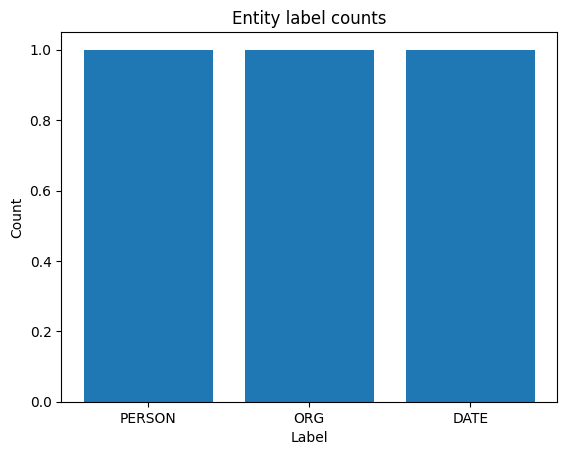

In [13]:
if counts:
    labels, values = zip(*counts.items())
    plt.figure()
    plt.bar(labels, values)
    plt.title("Entity label counts")
    plt.xlabel("Label")
    plt.ylabel("Count")
    plt.show()
else:
    print("No entities in text.")

## Custom Entity Rules
Use `EntityRuler` to add domain-specific entities (e.g., skills).

In [14]:
from spacy.pipeline import EntityRuler
ruler = nlp.add_pipe("entity_ruler", before="ner")
patterns = [
    {"label": "SKILL", "pattern": "Python"},
    {"label": "SKILL", "pattern": "Pandas"}
]
ruler.add_patterns(patterns)

doc2 = nlp("Python and Pandas are popular in data science.")
[(ent.text, ent.label_) for ent in doc2.ents]

[('Python', 'SKILL'), ('Pandas', 'SKILL')]

---
## Appendix: Utility helpers
- Re-run `doc = nlp(TEXT)` after you change `TEXT`.
- Use `displacy.serve(doc, style="dep")` for a standalone web view.
- Save tables: `df.to_csv("annotations.csv", index=False)`
Generated: 2025-11-06T14:19:55.034602Z
